<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/3dto2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

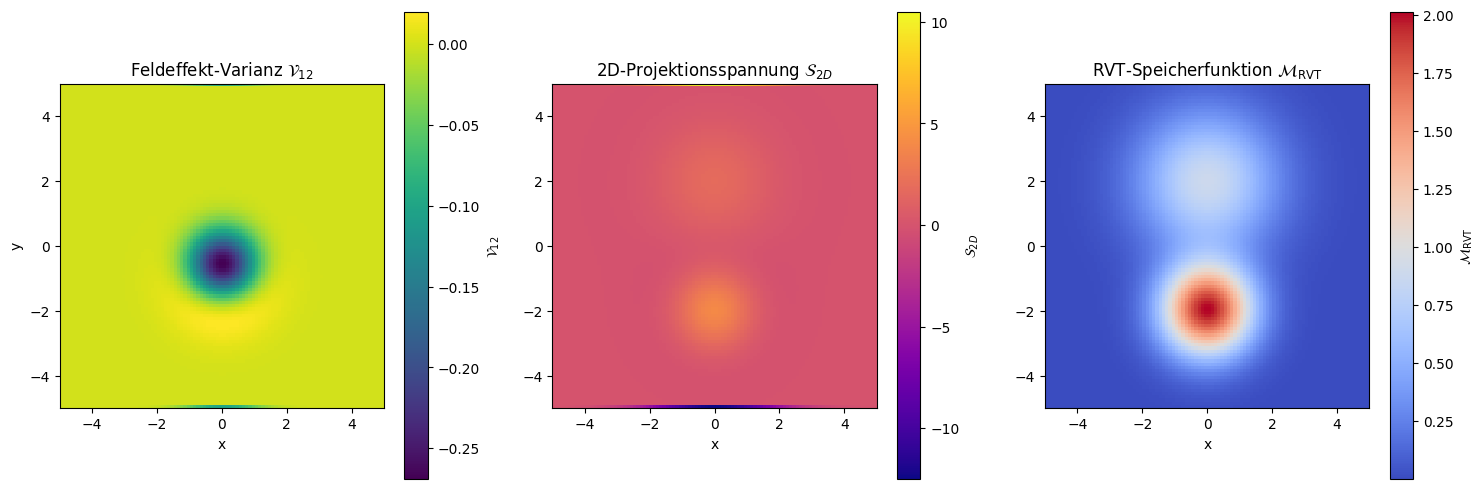

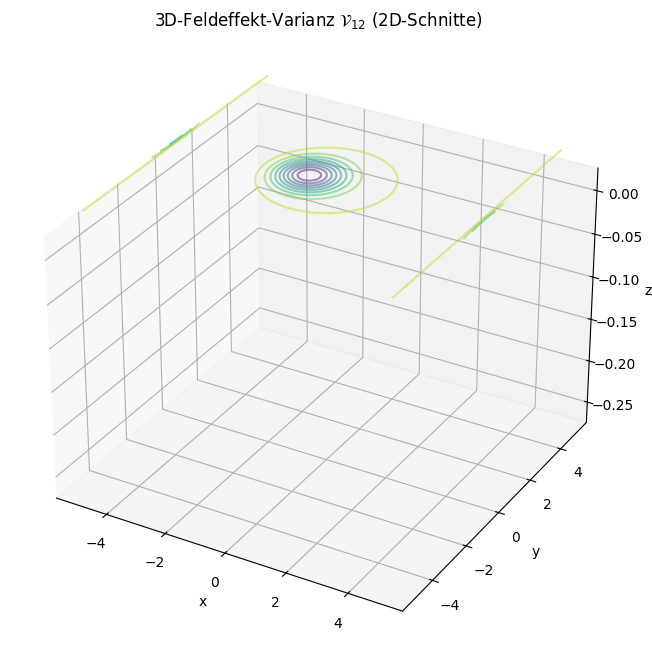

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter

# --- Parameter ---
N = 100  # Gitterpunkte
L = 10.0  # Systemgröße
alpha = 0.8  # Kopplungskonstante (RVT)
chi = 1.0    # Kopplungskonstante für M_RVT

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 (Gauß'sche Verteilungen) ---
Xi_1 = np.exp(-((X + 2)**2 + Y**2 + Z**2) / (2 * 1.0**2))
Xi_2 = np.exp(-((X - 2)**2 + Y**2 + Z**2) / (2 * 1.5**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (z.B. x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$')
plt.xlabel('x')
plt.ylabel('y')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x')

plt.tight_layout()
plt.savefig('RVT_Varianz_Simulation_2D.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurface in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurface für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (2D-Schnitte)')

plt.savefig('RVT_Varianz_3D_Schnitte.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter / Gitterfenster ---
# Angepasst für NGC 891 + M101:
# größeres Fenster, damit die Galaxienfelder nicht am Rand abgeschnitten werden.
N = 140          # Gitterpunkte: höher als 100, aber noch Colab-tauglich
L = 180.0        # Systemgröße in kpc: Fenster [-90, +90] kpc
alpha = 0.8      # RVT-Kopplungskonstante
chi = 1.0        # Kopplungskonstante für M_RVT

x_min, x_max = -L/2, L/2
y_min, y_max = -L/2, L/2
z_min, z_max = -L/2, L/2

# --- Beobachtete/Modell-Daten für NGC 891 und M101 ---
# NGC 891 (Edge-on): baryonische Masse ~5e10 M_Sun, Skalenlänge ~10 kpc
# M101 (Face-on):    baryonische Masse ~1e11 M_Sun, Skalenlänge ~15 kpc
#
# Wichtig: Die Zentren liegen weiter auseinander als vorher,
# aber innerhalb eines deutlich größeren Fensters.
center_891 = (-35.0, 0.0, 0.0)
center_M101 = (35.0, 0.0, 0.0)

mass_891 = 5e10
mass_M101 = 1e11

scale_891 = 10.0
scale_M101 = 15.0

# --- Gitter erstellen ---
x = np.linspace(x_min, x_max, N)
y = np.linspace(y_min, y_max, N)
z = np.linspace(z_min, z_max, N)

# indexing='ij' sorgt dafür, dass axis=0 -> x, axis=1 -> y, axis=2 -> z passt.
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) ---
Xi_1 = mass_891 * np.exp(-(
    (X - center_891[0])**2 +
    (Y - center_891[1])**2 +
    (Z - center_891[2])**2
) / (2 * scale_891**2))

Xi_2 = mass_M101 * np.exp(-(
    (X - center_M101[0])**2 +
    (Y - center_M101[1])**2 +
    (Z - center_M101[2])**2
) / (2 * scale_M101**2))

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, -1, axis=2) - np.roll(f, 1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = (x_max - x_min) / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
              np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
              np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
              6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (x-y-Ebene) ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- Visualisierung ---
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

extent_xy = [x_min, x_max, y_min, y_max]

plt.figure(figsize=(15, 5))

# Plot 1: Feldeffekt-Varianz V_12
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=extent_xy, cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=extent_xy, cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=extent_xy, cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (2D-Schnitte) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')

plt.savefig('RVT_Varianz_3D_NGC891_M101_grid180.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter / Gitterfenster ---
# Angepasst für NGC 891 + M101:
# gleiches Fenster wie in der zweiten Code-Zelle, aber mit RVT-Inklinationsfaktor.
N = 140
L = 180.0
C_RVT = 0.8

x_min, x_max = -L/2, L/2
y_min, y_max = -L/2, L/2
z_min, z_max = -L/2, L/2

# --- Inklinationswinkel ---
# NGC 891: 85° (Edge-on)
# M101:    18° (Face-on)
inclination_891 = np.radians(85)
inclination_M101 = np.radians(18)

# Optional: RVT-Gamma-Faktoren nur zur Kontrolle/Anzeige
gamma_891 = 1 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1 + C_RVT * np.sin(inclination_M101)

print(f"gamma_RVT(NGC 891, 85°) = {gamma_891:.3f}")
print(f"gamma_RVT(M101, 18°)    = {gamma_M101:.3f}")

# --- Modell-Daten ---
center_891 = (-35.0, 0.0, 0.0)
center_M101 = (35.0, 0.0, 0.0)

mass_891 = 5e10
mass_M101 = 1e11

scale_891 = 10.0
scale_M101 = 15.0

# --- Gitter erstellen ---
x = np.linspace(x_min, x_max, N)
y = np.linspace(y_min, y_max, N)
z = np.linspace(z_min, z_max, N)

# indexing='ij' sorgt dafür, dass axis=0 -> x, axis=1 -> y, axis=2 -> z passt.
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) ---
# Hier mit RVT-Inklinationsprojektion sin(i).
Xi_1 = mass_891 * np.exp(-(
    (X - center_891[0])**2 +
    (Y - center_891[1])**2 +
    (Z - center_891[2])**2
) / (2 * scale_891**2)) * np.sin(inclination_891)

Xi_2 = mass_M101 * np.exp(-(
    (X - center_M101[0])**2 +
    (Y - center_M101[1])**2 +
    (Z - center_M101[2])**2
) / (2 * scale_M101**2)) * np.sin(inclination_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, -1, axis=2) - np.roll(f, 1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = (x_max - x_min) / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 mit Kopplungsfaktor ---
V_12 = 2 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
              np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
              np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
              6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (x-y-Ebene) ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- Visualisierung ---
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

extent_xy = [x_min, x_max, y_min, y_max]

plt.figure(figsize=(15, 5))

# Plot 1: Feldeffekt-Varianz V_12
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=extent_xy, cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101, inkl.)')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=extent_xy, cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=extent_xy, cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (2D-Schnitte) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101, inkl.)')

plt.savefig('RVT_Varianz_3D_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()